# 4. Query and Visualize Data

This notebook demonstrates DataJoint query operations and data visualization for the LC-MS pipeline.

In [1]:
from lcms_demo.config import use_local_database

use_local_database()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from lcms_demo.pipeline import subject, session, scan

[2026-02-06 01:50:22][WARNING]: SSL connection failed (connection to server at "localhost" (::1), port 5432 failed: server does not support SSL, but SSL was required
). Falling back to non-SSL connection. To require SSL, set use_tls=True explicitly.


[2026-02-06 01:50:22] DataJoint 2.1.0 connected to datajoint@localhost:5432


## Basic Queries

### Fetch All Data

In [3]:
# View subjects table
subject.Subject()

subject_id,subject_description
MANUAL_001,Manually entered subject
SUBJ_001,Demo subject SUBJ_001
SUBJ_002,Demo subject SUBJ_002
SUBJ_003,Demo subject SUBJ_003


In [4]:
# Fetch all subjects as a pandas DataFrame
subjects_df = subject.Subject.to_pandas()
subjects_df

,subject_description
subject_id,
SUBJ_001,Demo subject SUBJ_001
SUBJ_002,Demo subject SUBJ_002
SUBJ_003,Demo subject SUBJ_003
MANUAL_001,Manually entered subject


### Restriction (Filtering)

In [5]:
# Filter samples by type
subject.Sample & "sample_type = 'plasma'"

subject_id None,sample_id,"sample_type e.g., plasma, liver, urine",collection_datetime,sample_description
MANUAL_001,plasma_01,plasma,None,
SUBJ_001,SAMPLE_001,plasma,2026-02-06 01:50:04.110828,Demo sample SAMPLE_001
SUBJ_002,SAMPLE_001,plasma,2026-02-06 01:50:04.118624,Demo sample SAMPLE_001
SUBJ_003,SAMPLE_001,plasma,2026-02-06 01:50:04.121813,Demo sample SAMPLE_001


In [6]:
# Filter scans by retention time window
scan.Scans.Scan & "retention_time BETWEEN 5 AND 10"

subject_id None,sample_id None,session_datetime None,scan_number,retention_time minutes,"ms_level 1=MS1, 2=MS2",total_ion_current,base_peak_mz,base_peak_intensity
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,21,5.1938775510204085,1,101557808.0,400.9009094238281,1351527.625
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,22,5.428571428571429,1,121570472.0,218.0180206298828,984586.375
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,23,5.663265306122449,1,108668144.0,845.9459228515625,1536053.25
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,24,5.8979591836734695,1,123520232.0,602.7026977539062,1858299.0
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,25,6.13265306122449,1,141222944.0,427.92791748046875,1110893.875
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,26,6.36734693877551,1,108383040.0,863.9639892578125,1106510.375
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,27,6.6020408163265305,1,106742304.0,271.1711730957031,1388920.125
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,28,6.836734693877552,1,127753296.0,504.5045166015625,1803841.75
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,29,7.071428571428572,1,115888504.0,478.3783874511719,1127741.875
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,30,7.306122448979592,1,124659712.0,829.729736328125,1338813.375


### Projection (Selecting Columns)

In [7]:
# Select and rename attributes
scan.Scans.Scan.proj(rt="retention_time", tic="total_ion_current")

subject_id None,sample_id None,session_datetime None,scan_number,retention_time minutes,"ms_level 1=MS1, 2=MS2",total_ion_current,base_peak_mz,base_peak_intensity
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,1,bytes,bytes,bytes,bytes,bytes
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,2,bytes,bytes,bytes,bytes,bytes
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,3,bytes,bytes,bytes,bytes,bytes
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,4,bytes,bytes,bytes,bytes,bytes
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,5,bytes,bytes,bytes,bytes,bytes
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,6,bytes,bytes,bytes,bytes,bytes
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,7,bytes,bytes,bytes,bytes,bytes
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,8,bytes,bytes,bytes,bytes,bytes
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,9,bytes,bytes,bytes,bytes,bytes
SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,10,bytes,bytes,bytes,bytes,bytes


### Join Operations

In [8]:
# Join tables to get combined information
subject.Subject * subject.Sample

subject_id None,sample_id,"sample_type e.g., plasma, liver, urine",collection_datetime,sample_description,subject_description
MANUAL_001,liver_01,liver,None,,Manually entered subject
MANUAL_001,plasma_01,plasma,None,,Manually entered subject
SUBJ_001,SAMPLE_001,plasma,2026-02-06 01:50:04.110828,Demo sample SAMPLE_001,Demo subject SUBJ_001
SUBJ_001,SAMPLE_002,liver,2026-02-06 01:50:04.116748,Demo sample SAMPLE_002,Demo subject SUBJ_001
SUBJ_002,SAMPLE_001,plasma,2026-02-06 01:50:04.118624,Demo sample SAMPLE_001,Demo subject SUBJ_002
SUBJ_002,SAMPLE_002,liver,2026-02-06 01:50:04.119951,Demo sample SAMPLE_002,Demo subject SUBJ_002
SUBJ_003,SAMPLE_001,plasma,2026-02-06 01:50:04.121813,Demo sample SAMPLE_001,Demo subject SUBJ_003
SUBJ_003,SAMPLE_002,liver,2026-02-06 01:50:04.123116,Demo sample SAMPLE_002,Demo subject SUBJ_003


### Aggregation

In [9]:
# Count scans per session using the Scans master table
session.Session.aggr(scan.Scans, n_scans="n_scans")

QuerySyntaxError: ('syntax error at or near "as"\nLINE 1: ...ject_id","sample_id","session_datetime",`n_scans` as "n_scan...\n                                                             ^\n', '')

QuerySyntaxError: ('syntax error at or near "as"\nLINE 1: ...ject_id","sample_id","session_datetime",`n_scans` as "n_scan...\n                                                             ^\n', '')

---

## Data Visualization

### Total Ion Chromatogram (TIC)

The TIC shows the total ion current as a function of retention time.

In [10]:
# Get the first session
first_session_query = session.Session & {'subject_id': 'SUBJ_001', 'sample_id': 'SAMPLE_001'}
first_session = first_session_query.to_dicts()[0]
print(f"Session: {first_session['subject_id']} / {first_session['sample_id']}")

# Fetch scan data from Part table (reset_index to include PK columns)
scans_df = (scan.Scans.Scan & first_session_query).to_pandas().reset_index()
scans_df = scans_df.sort_values('scan_number').reset_index(drop=True)

scans_df.head()

Session: SUBJ_001 / SAMPLE_001


,subject_id,sample_id,session_datetime,scan_number,retention_time,ms_level,total_ion_current,base_peak_mz,base_peak_intensity
0,SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,1,0.500000,1,117122608.0,675.675659,1196373.750
1,SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,2,0.734694,1,112111464.0,149.549545,1232484.375
2,SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,3,0.969388,1,82608608.0,153.153152,1090651.875
3,SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,4,1.204082,1,109376128.0,528.828857,1275362.000
4,SUBJ_001,SAMPLE_001,2026-02-06 01:50:04.111423,5,1.438776,1,103797952.0,481.081085,1610641.250


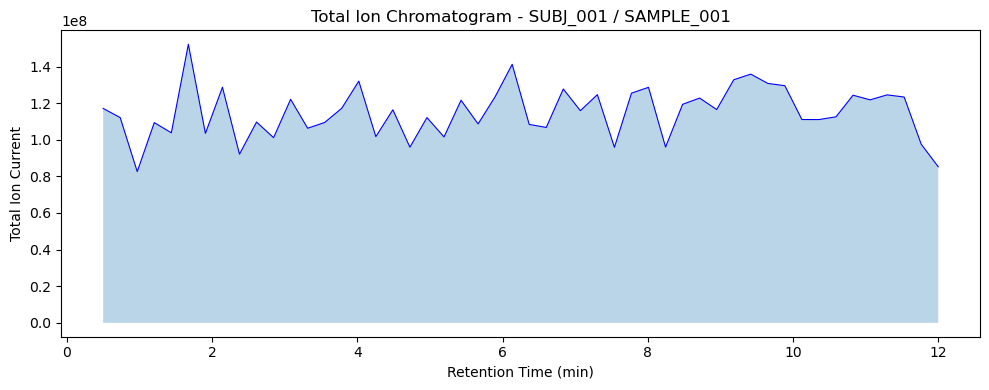

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(scans_df['retention_time'], scans_df['total_ion_current'], 'b-', linewidth=0.8)
ax.fill_between(scans_df['retention_time'], scans_df['total_ion_current'], alpha=0.3)

ax.set_xlabel('Retention Time (min)')
ax.set_ylabel('Total Ion Current')
ax.set_title(f"Total Ion Chromatogram - {first_session['subject_id']} / {first_session['sample_id']}")
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()

### Base Peak Chromatogram (BPC)

The BPC shows the intensity of the most intense peak at each scan.

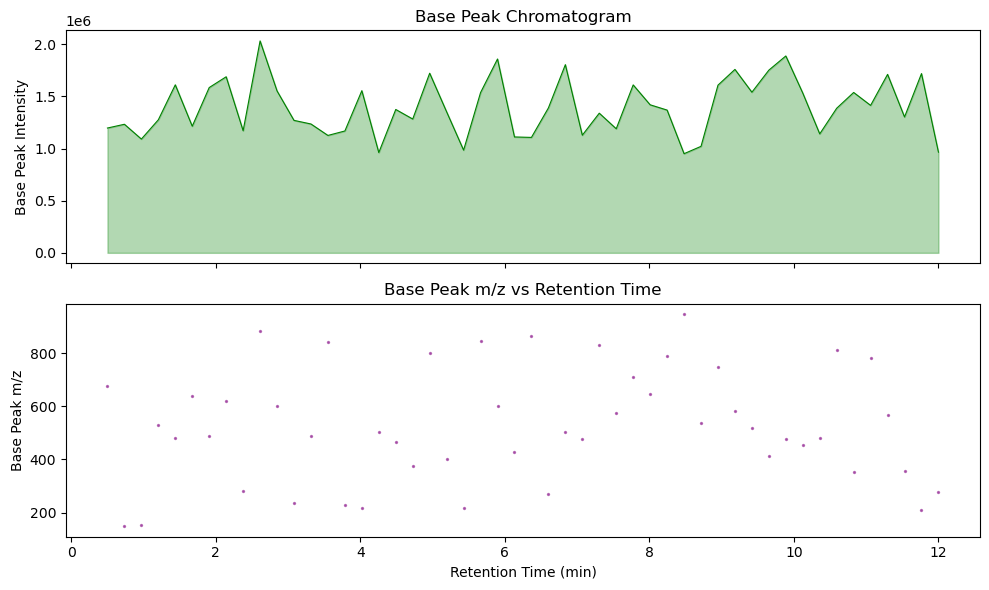

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Base peak intensity
axes[0].plot(scans_df['retention_time'], scans_df['base_peak_intensity'], 'g-', linewidth=0.8)
axes[0].fill_between(scans_df['retention_time'], scans_df['base_peak_intensity'], alpha=0.3, color='green')
axes[0].set_ylabel('Base Peak Intensity')
axes[0].set_title('Base Peak Chromatogram')
axes[0].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Base peak m/z
axes[1].scatter(scans_df['retention_time'], scans_df['base_peak_mz'], s=2, alpha=0.5, c='purple')
axes[1].set_xlabel('Retention Time (min)')
axes[1].set_ylabel('Base Peak m/z')
axes[1].set_title('Base Peak m/z vs Retention Time')

plt.tight_layout()
plt.show()

### Mass Spectrum

Display a single mass spectrum from the dataset.

In [13]:
# Get spectrum for scan at peak TIC
peak_idx = scans_df['total_ion_current'].idxmax()
peak_scan = scans_df.iloc[peak_idx]

# Get spectrum from Part table (use same session restriction)
spectrum_query = (
    scan.Spectra.Spectrum 
    & first_session_query 
    & {'scan_number': int(peak_scan['scan_number'])}
)
spectrum = spectrum_query.to_dicts()[0]
print(f"Spectrum at RT = {peak_scan['retention_time']:.2f} min (scan #{peak_scan['scan_number']})")

Spectrum at RT = 1.67 min (scan #6)


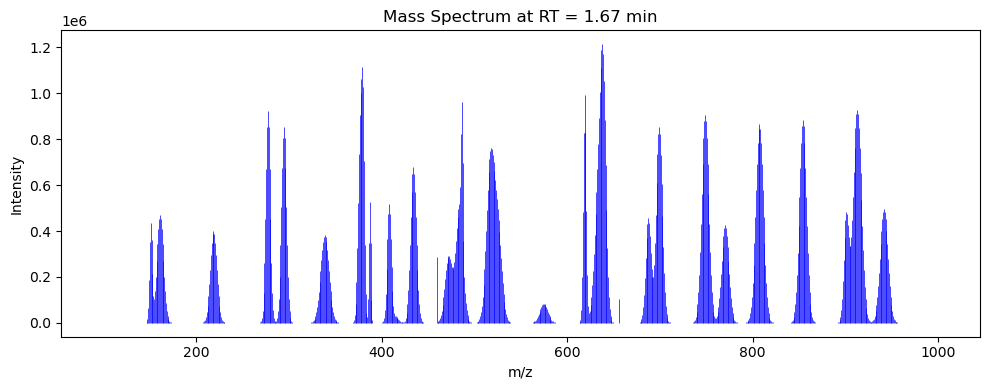

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))

mz = spectrum['mz_array']
intensity = spectrum['intensity_array']

# Plot as stem plot for mass spectrum
ax.vlines(mz, 0, intensity, linewidth=0.5, color='blue')

ax.set_xlabel('m/z')
ax.set_ylabel('Intensity')
ax.set_title(f"Mass Spectrum at RT = {peak_scan['retention_time']:.2f} min")
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()

### Zoomed Spectrum Region

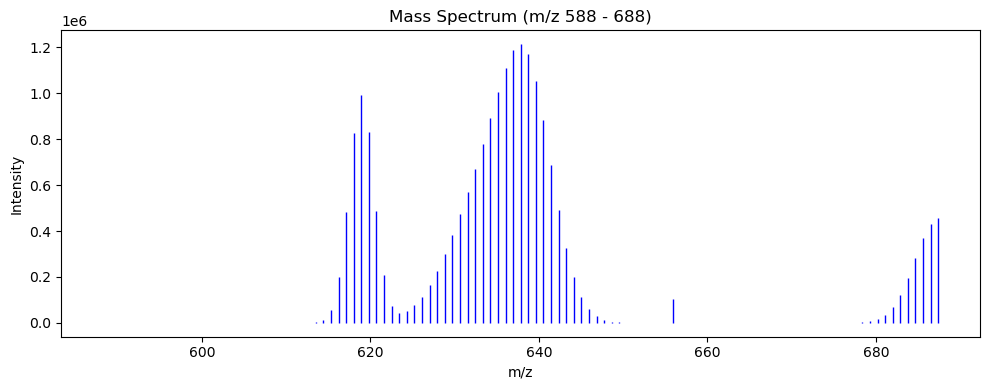

In [15]:
# Zoom into a region around the base peak
base_peak_mz = mz[np.argmax(intensity)]
window = 50  # +/- 50 Da

mask = (mz >= base_peak_mz - window) & (mz <= base_peak_mz + window)

fig, ax = plt.subplots(figsize=(10, 4))

ax.vlines(mz[mask], 0, intensity[mask], linewidth=1, color='blue')

ax.set_xlabel('m/z')
ax.set_ylabel('Intensity')
ax.set_title(f"Mass Spectrum (m/z {base_peak_mz-window:.0f} - {base_peak_mz+window:.0f})")
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()

### Detected Peaks

Visualize the peaks detected by the Peaks computed table.

In [16]:
# Check if peaks have been computed for this session
peaks_query = scan.Peaks & first_session_query

if peaks_query:
    peak_data = peaks_query.to_dicts()[0]
    total_peaks = peak_data['total_peaks']
    
    # Get individual peaks for the specific scan
    scan_peaks = (
        scan.Peaks.Peak 
        & first_session_query 
        & {'scan_number': int(peak_scan['scan_number'])}
    ).to_pandas().reset_index(drop=True)
    
    print(f"Detected {len(scan_peaks)} peaks in scan #{int(peak_scan['scan_number'])}")
    print(f"Total peaks in session: {total_peaks}")
    display(scan_peaks.head(10))
else:
    print("No peaks detected yet. Run Peaks.populate() to detect peaks.")
    scan_peaks = None

Detected 27 peaks in scan #6
Total peaks in session: 1289


,mz,intensity,snr
0,151.351349,4.354833e+05,36.434717
1,161.261261,4.695738e+05,39.286900
2,218.918915,3.998138e+05,33.450428
3,277.477478,9.218464e+05,77.126295
4,294.594604,8.518846e+05,71.272944
5,338.738739,3.809836e+05,31.875002
6,379.279266,1.115508e+06,93.328998
7,387.387390,5.259686e+05,44.005175
8,408.108093,5.170425e+05,43.258368
9,434.234222,6.784536e+05,56.762830


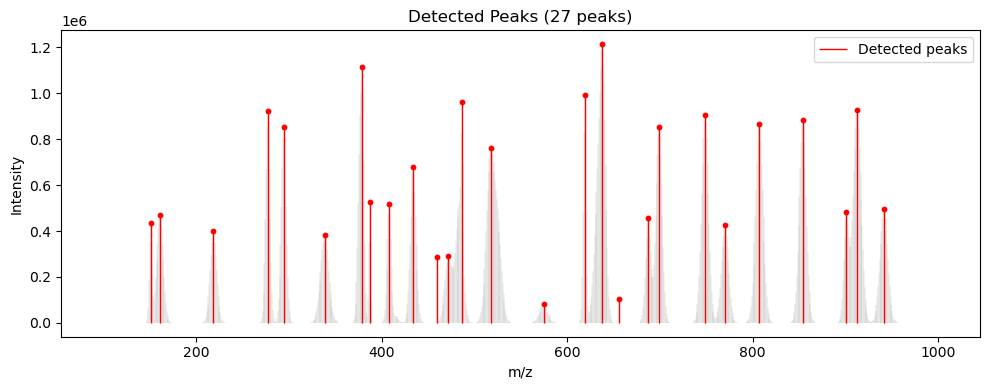

In [17]:
if scan_peaks is not None and len(scan_peaks) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Plot full spectrum
    ax.vlines(mz, 0, intensity, linewidth=0.3, color='gray', alpha=0.5)
    
    # Overlay detected peaks
    ax.vlines(scan_peaks['mz'], 0, scan_peaks['intensity'], linewidth=1, color='red', label='Detected peaks')
    ax.scatter(scan_peaks['mz'], scan_peaks['intensity'], s=10, color='red', zorder=5)
    
    ax.set_xlabel('m/z')
    ax.set_ylabel('Intensity')
    ax.set_title(f"Detected Peaks ({len(scan_peaks)} peaks)")
    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    ax.legend()
    
    plt.tight_layout()
    plt.show()

### Peak Statistics

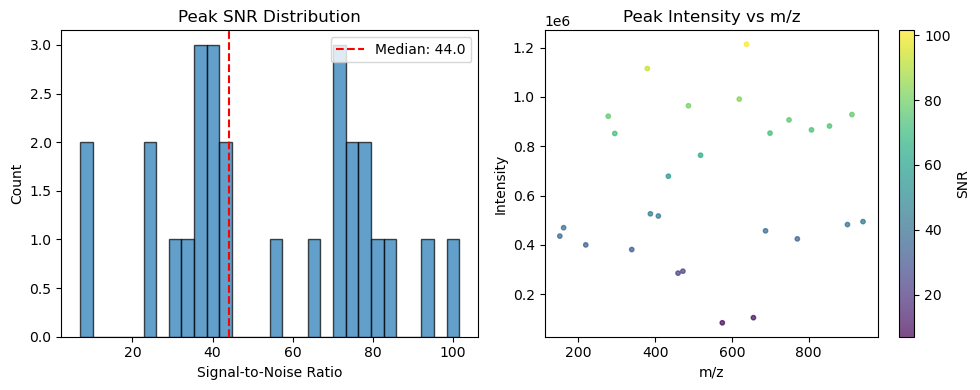

In [18]:
if scan_peaks is not None and len(scan_peaks) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # SNR distribution
    axes[0].hist(scan_peaks['snr'], bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Signal-to-Noise Ratio')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Peak SNR Distribution')
    axes[0].axvline(scan_peaks['snr'].median(), color='red', linestyle='--', label=f"Median: {scan_peaks['snr'].median():.1f}")
    axes[0].legend()
    
    # m/z vs intensity
    scatter = axes[1].scatter(scan_peaks['mz'], scan_peaks['intensity'], c=scan_peaks['snr'], s=10, cmap='viridis', alpha=0.7)
    axes[1].set_xlabel('m/z')
    axes[1].set_ylabel('Intensity')
    axes[1].set_title('Peak Intensity vs m/z')
    axes[1].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    plt.colorbar(scatter, ax=axes[1], label='SNR')
    
    plt.tight_layout()
    plt.show()

## Summary Statistics

In [19]:
print("Pipeline Summary")
print("=" * 40)
print(f"Subjects:      {len(subject.Subject()):>6}")
print(f"Samples:       {len(subject.Sample()):>6}")
print(f"Sessions:      {len(session.Session()):>6}")
print(f"Scans:         {len(scan.Scans()):>6}")
print(f"  - Scan data: {len(scan.Scans.Scan()):>6}")
print(f"Spectra:       {len(scan.Spectra()):>6}")
print(f"  - Spectrum:  {len(scan.Spectra.Spectrum()):>6}")
print(f"Peaks:         {len(scan.Peaks()):>6}")
print(f"  - Peak data: {len(scan.Peaks.Peak()):>6}")

Pipeline Summary
Subjects:           4
Samples:            8
Sessions:           6
Scans:              6
  - Scan data:    300
Spectra:            6
  - Spectrum:     300
Peaks:              6
  - Peak data:   7769
